In [1]:
# A bunch of plotting stuff for our paper. We're gonna do this separately to make plotting easier after we've done all the data processing
import os
import pandas as pd
import numpy as np
import scipy as sp

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns

import plotly.express as px
from plotly import graph_objects as go

import dask
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

# Funnel Plot to show how filtering works
## We'll do this in plotly as it's kind of the only plotting framework that vaguely works for this

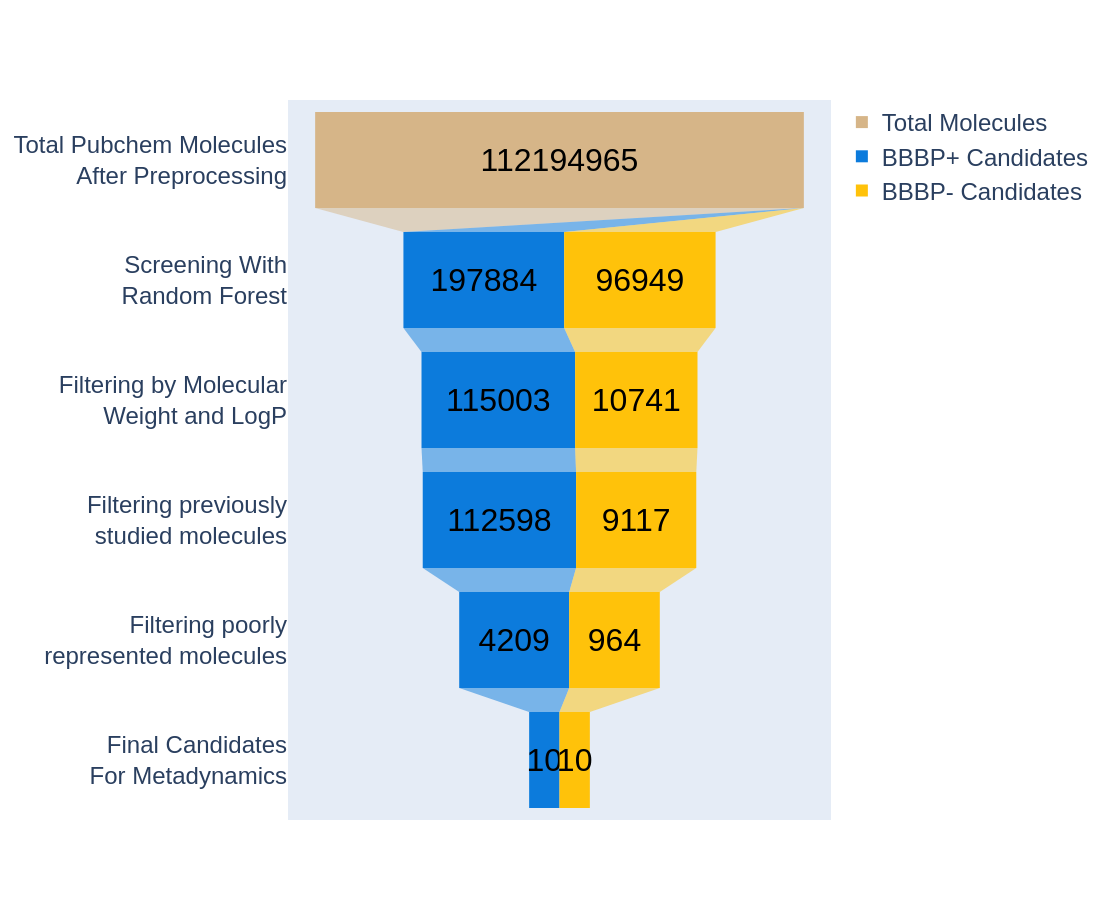

In [2]:
# Do the funnel plot
stages = [
    'Total Pubchem Molecules<br> After Preprocessing',
    'Screening With<br> Random Forest',
    'Filtering by Molecular<br> Weight and LogP',
    'Filtering previously<br> studied molecules',
    'Filtering poorly<br> represented molecules',
    'Final Candidates<br> For Metadynamics'
]

fig = go.Figure()


fig.add_trace(go.Funnel(
    name = 'Total Molecules',
    y = stages,
    x = [np.log10(112194965)*2, 0, 0, 0, 0], # Multiply by 2 to keep consistent with the scale of the rest of the plot
    text = [112194965, None, None, None],
    textposition="inside",
    textinfo="text",
    constraintext='outside',
    marker={"color": "#D6B588"},
    textfont=dict(
        size=32,
        color="black"
    ),
))

fig.add_trace(go.Funnel(
    name = 'BBBP+ Candidates',
    y = stages,
    x = np.log10([1, 197884, 115003, 112598, 4209, 10]),
    text = [None, 197884, 115003, 112598, 4209, 10],
    textposition="inside",
    textinfo="text",
    constraintext='outside',
    marker={"color": "#0C7BDC"},
    textfont=dict(
        size=32,
        color="black"
    ),
))

fig.add_trace(go.Funnel(
    name = 'BBBP- Candidates',
    y = stages,
    x = np.log10([1, 96949, 10741, 9117, 964, 10]),
    text = [None, 96949, 10741, 9117, 964, 10],
    textposition="inside",
    textinfo="text",
    constraintext='outside',
    marker={"color": "#FFC20A"},
    textfont=dict(
        size=32,
        color="black"
    ),
))

fig.update_layout(
    #xaxis_type="log", # Do this manually or things get real fucky
    #title=dict(text="Candidate Molecules Funnel Plot (Logarithmic Scale)", automargin=True),
    xaxis_title="Number of Candidates",
    font=dict(
        #family="Courier New, monospace",
        size=24,
        #color="RebeccaPurple"
    ),
    width=1600,
    height=900,
)

fig.write_image(
    "funnel_pubchem.png",
    width=1600,
    height=900,
)
fig.show()

# Plot all the energy barriers of each candidate using box plots

In [3]:
def read_fe_csv(fn):
    data = pd.read_csv( # Read free energy data from plumed outputs
        fn,
        comment='#',
        sep='\\s+',
        names=['d_abs', 'G', 'dG']
        )
    # Remove out of bounds data
    data = data[(data['d_abs'] > 0) * (data['d_abs'] < 8)]
    # We should shift the zero point of the free energy to the value in the water
    zero_point = data['G'][data['d_abs'] > 7.0].mean()
    data['G'] -= zero_point
    return data

def load_fes(fn, pos_cand, neg_cand):

    reference_molecules = ['trihexyphenidyl', 'isopropanol', 'caffeine', 'morphine-6-glucuronide', 'sucrose']
    reference_fes = {}

    for rm in reference_molecules:
        reference_fes[rm] = read_fe_csv(f'{fn}/gromacs/{rm}/fes.dat')

    pos_fes = {}
    for i, idx in enumerate(pos_cand['idx']):
        pos_fes[idx] = read_fe_csv(f'{fn}/candidates/pos/{idx}/fes.dat')

    neg_fes = {}
    for i, idx in enumerate(neg_cand['idx']):
        neg_fes[idx] = read_fe_csv(f'{fn}/candidates/neg/{idx}/fes.dat')

    return reference_fes, pos_fes, neg_fes

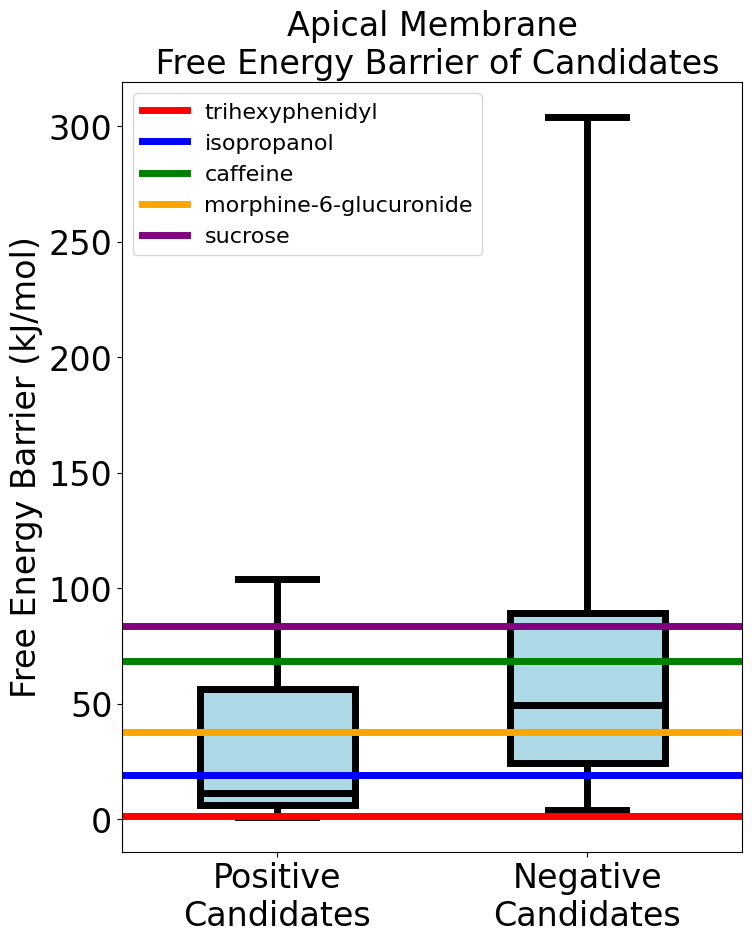

In [4]:
# If no arguments are provided, use our hardcoded values
cmap = plt.get_cmap('viridis')
reference_colors = ['red', 'blue', 'green', 'orange', 'purple']

# colon for comments because # is already used
pos_cand = pd.read_csv('../common/candidates/bbbp_positive_pubchem.csv', comment=';') 
neg_cand = pd.read_csv('../common/candidates/bbbp_negative_pubchem.csv', comment=';')

apical_reference_fes, apical_pos_fes, apical_neg_fes = load_fes(
    fn='../apical',
    pos_cand=pos_cand,
    neg_cand=neg_cand
)

plt.figure(figsize=(8, 10))
plt.title('Apical Membrane\n Free Energy Barrier of Candidates', fontsize=24)
pos_barriers = [apical_pos_fes[idx]['G'].max() for idx in pos_cand['idx']]
neg_barriers = [apical_neg_fes[idx]['G'].max() for idx in neg_cand['idx']]
plt.boxplot(
    [pos_barriers, neg_barriers],
    positions=[1, 2],
    widths=0.5, whis=[0, 100],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black', linewidth=5),
    medianprops=dict(color='black', linewidth=5),
    whiskerprops=dict(color='black', linewidth=5),
    capprops=dict(color='black', linewidth=5)
    )
plt.xticks([1, 2], ['Positive\nCandidates', 'Negative\nCandidates'], fontsize=24)
plt.yticks(fontsize=24)
plt.ylabel('Free Energy Barrier (kJ/mol)', fontsize=24)

# Add our reference molecules as horizontal lines
for i, rm in enumerate(apical_reference_fes):
    plt.axhline(
        apical_reference_fes[rm]['G'].max(),
        label=rm, color=reference_colors[i],
        linewidth=5,
        )
plt.legend(fontsize=16)
plt.savefig('apical_candidates_boxplot.png')

In [5]:
print("Performing Mann Whitney U Test for Apical Free Energy Barrier")
# Our alternate hypothesis is that neg_barriers > pos_barriers
test_res = sp.stats.mannwhitneyu(neg_barriers, pos_barriers, alternative="greater", method="exact")
print("Mann Whitney U statistic:", test_res.statistic, " p value:", test_res.pvalue)

Performing Mann Whitney U Test for Apical Free Energy Barrier
Mann Whitney U statistic: 69.0  p value: 0.08274697438784127


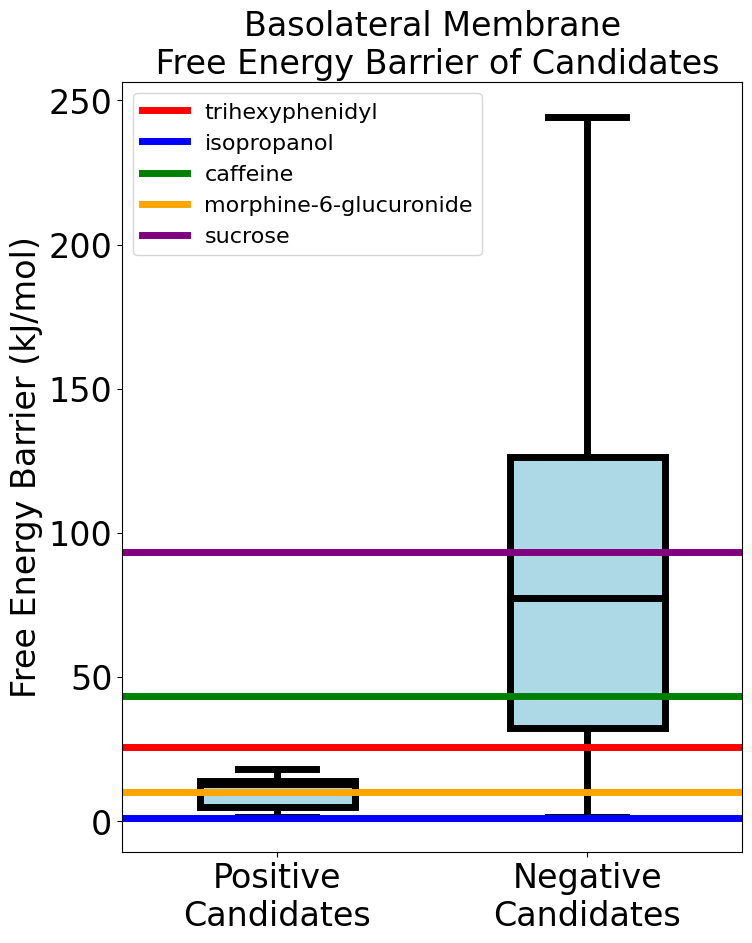

In [6]:
basolateral_reference_fes, basolateral_pos_fes, basolateral_neg_fes = load_fes(
    fn='../basolateral',
    pos_cand=pos_cand,
    neg_cand=neg_cand
)

plt.figure(figsize=(8, 10))
plt.title('Basolateral Membrane\n Free Energy Barrier of Candidates', fontsize=24)
pos_barriers = [basolateral_pos_fes[idx]['G'].max() for idx in pos_cand['idx']]
neg_barriers = [basolateral_neg_fes[idx]['G'].max() for idx in neg_cand['idx']]
plt.boxplot(
    [pos_barriers, neg_barriers],
    positions=[1, 2],
    widths=0.5, whis=[0, 100],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black', linewidth=5),
    medianprops=dict(color='black', linewidth=5),
    whiskerprops=dict(color='black', linewidth=5),
    capprops=dict(color='black', linewidth=5)
    )
plt.xticks([1, 2], ['Positive\nCandidates', 'Negative\nCandidates'], fontsize=24)
plt.yticks(fontsize=24)
plt.ylabel('Free Energy Barrier (kJ/mol)', fontsize=24)

# Add our reference molecules as horizontal lines
for i, rm in enumerate(basolateral_reference_fes):
    plt.axhline(
        basolateral_reference_fes[rm]['G'].max(),
        label=rm, color=reference_colors[i],
        linewidth=5,
        )
plt.legend(fontsize=16)
plt.savefig('basolateral_candidates_boxplot.png')

In [7]:
print("Performing Mann Whitney U Test for Basolateral Free Energy Barrier")
# Our alternate hypothesis is that neg_barriers > pos_barriers
test_res = sp.stats.mannwhitneyu(neg_barriers, pos_barriers, alternative="greater", method="exact")
print("Mann Whitney U statistic:", test_res.statistic, " p value:", test_res.pvalue)

Performing Mann Whitney U Test for Basolateral Free Energy Barrier
Mann Whitney U statistic: 89.0  p value: 0.0010446210136612613


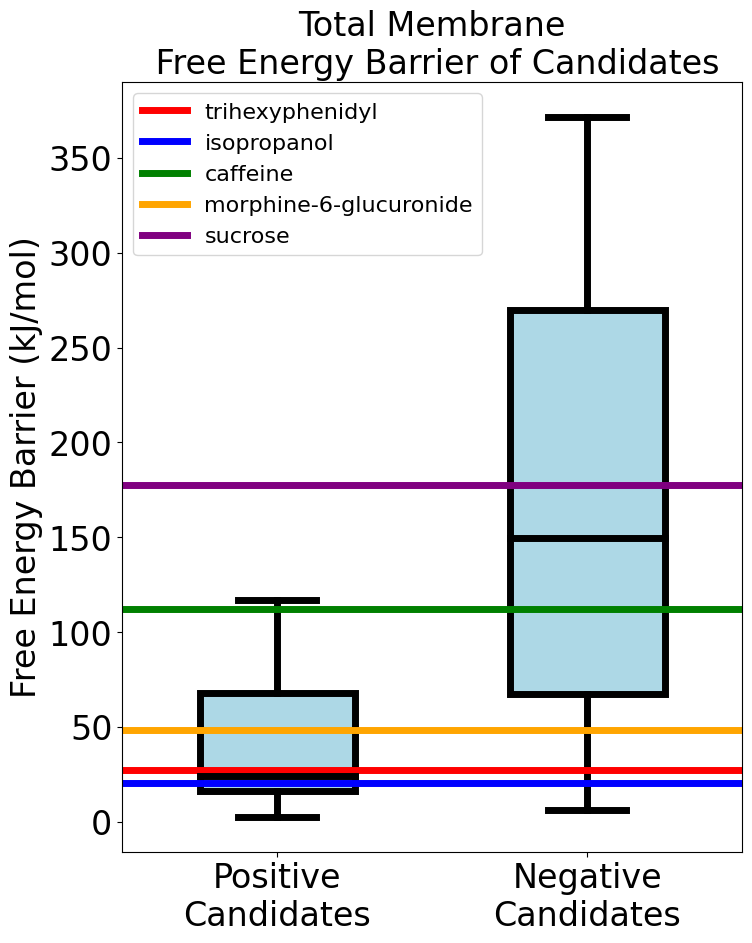

In [8]:
plt.figure(figsize=(8, 10))
plt.title('Total Membrane\n Free Energy Barrier of Candidates', fontsize=24)
pos_barriers = [apical_pos_fes[idx]['G'].max() + basolateral_pos_fes[idx]['G'].max() for idx in apical_pos_fes]
neg_barriers = [apical_neg_fes[idx]['G'].max() + basolateral_neg_fes[idx]['G'].max() for idx in apical_neg_fes]

reference_barriers = dict(
    [(rm, apical_reference_fes[rm]['G'].max() + basolateral_reference_fes[rm]['G'].max()) for rm in apical_reference_fes]
)

plt.boxplot(
    [pos_barriers, neg_barriers],
    positions=[1, 2],
    widths=0.5, whis=[0, 100],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black', linewidth=5),
    medianprops=dict(color='black', linewidth=5),
    whiskerprops=dict(color='black', linewidth=5),
    capprops=dict(color='black', linewidth=5)
    )
plt.xticks([1, 2], ['Positive\nCandidates', 'Negative\nCandidates'], fontsize=24)
plt.yticks(fontsize=24)
plt.ylabel('Free Energy Barrier (kJ/mol)', fontsize=24)

# Add our reference molecules as horizontal lines
for i, rm in enumerate(reference_barriers):
    plt.axhline(
        reference_barriers[rm],
        label=rm, color=reference_colors[i],
        linewidth=5,
        )
plt.legend(fontsize=16)
plt.savefig('total_candidates_boxplot.png')


In [9]:
print("Performing Mann Whitney U Test for Total Free Energy Barrier")
# We don't need continuity correction because our data is continuous, as far as I understand it
# Our alternate hypothesis is that neg_barriers > pos_barriers
test_res = sp.stats.mannwhitneyu(neg_barriers, pos_barriers, alternative="greater", method="exact")
print("Mann Whitney U statistic:", test_res.statistic, " p value:", test_res.pvalue)

Performing Mann Whitney U Test for Total Free Energy Barrier
Mann Whitney U statistic: 83.0  p value: 0.0057481218471930546


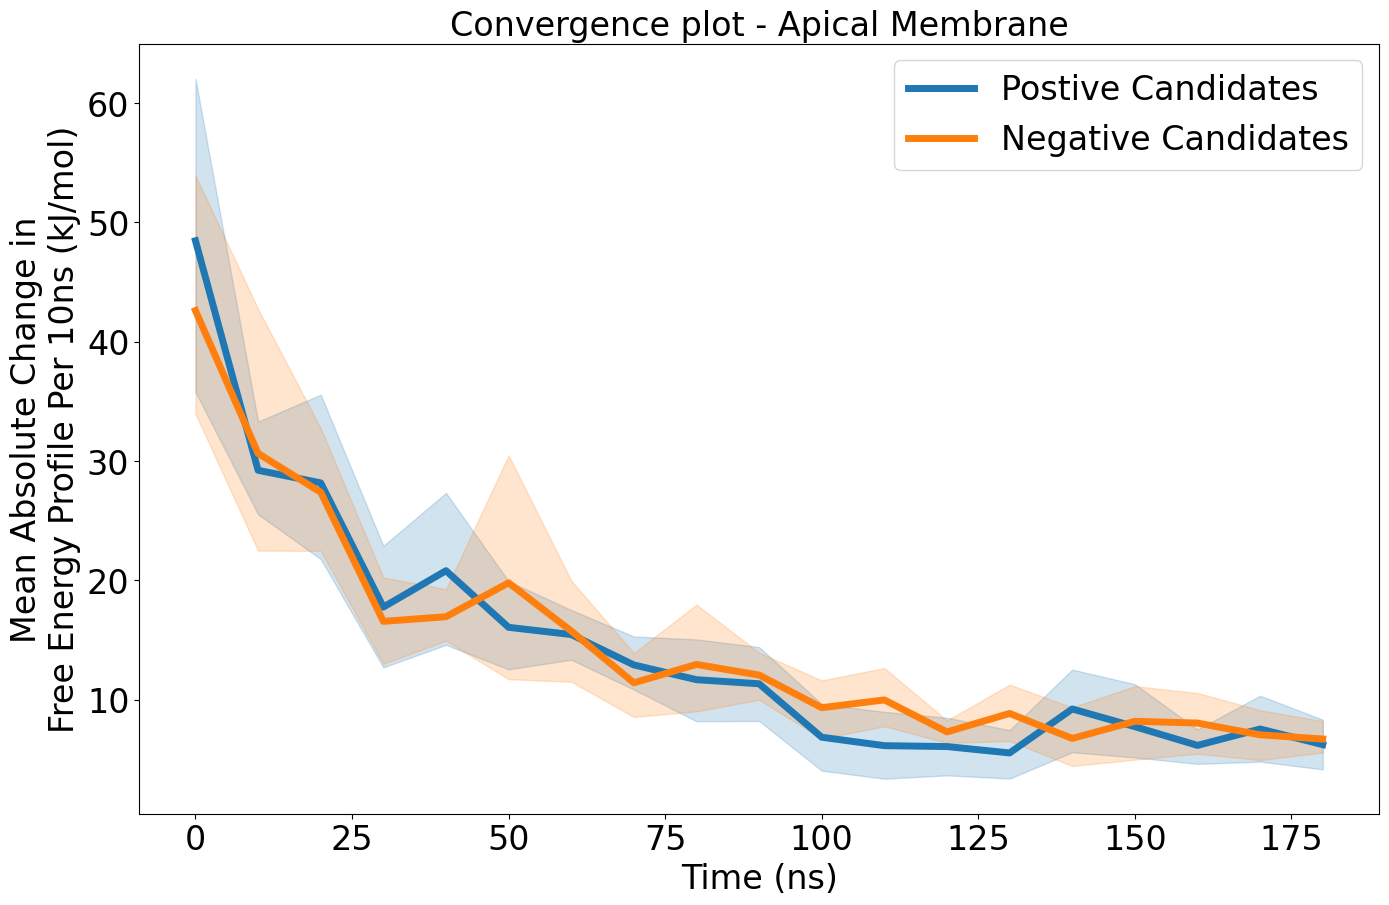

In [10]:
def compute_convergence(fn):
    hill_fes = []
    for i in range(21):
        hill_fes += [read_fe_csv(f'{fn}/fes_{i}.dat')]
    
    time = []
    dG = []
    for i in range(19):
        time += [i * 2 * 10000 * 500/(10**6)]
        dG += [np.mean(np.abs(hill_fes[i+1]['G'] - hill_fes[i]['G']))]

    return pd.DataFrame(
        columns=['time', 'dG'],
        data={'time': time, 'dG': dG}
        )

plt.figure(figsize=(16,10))
plt.title('Convergence plot - Apical Membrane', fontsize=24)
pos_convergence = []
for i, idx in enumerate(pos_cand['idx']):
    pos_convergence += [compute_convergence(f'../apical/candidates/pos/{idx}')]
pos_convergence = pd.concat(pos_convergence)

neg_convergence = []
for i, idx in enumerate(neg_cand['idx']):
    neg_convergence += [compute_convergence(f'../apical/candidates/neg/{idx}')]
neg_convergence = pd.concat(neg_convergence)

sns.lineplot(data=pos_convergence, x='time', y='dG', label='Postive Candidates', linewidth=5)
sns.lineplot(data=neg_convergence, x='time', y='dG', label='Negative Candidates', linewidth=5)
plt.xlabel('Time (ns)', fontsize=24)
plt.ylabel('Mean Absolute Change in\nFree Energy Profile Per 10ns (kJ/mol)', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(fontsize=24)
plt.savefig('convergence_apical.png')


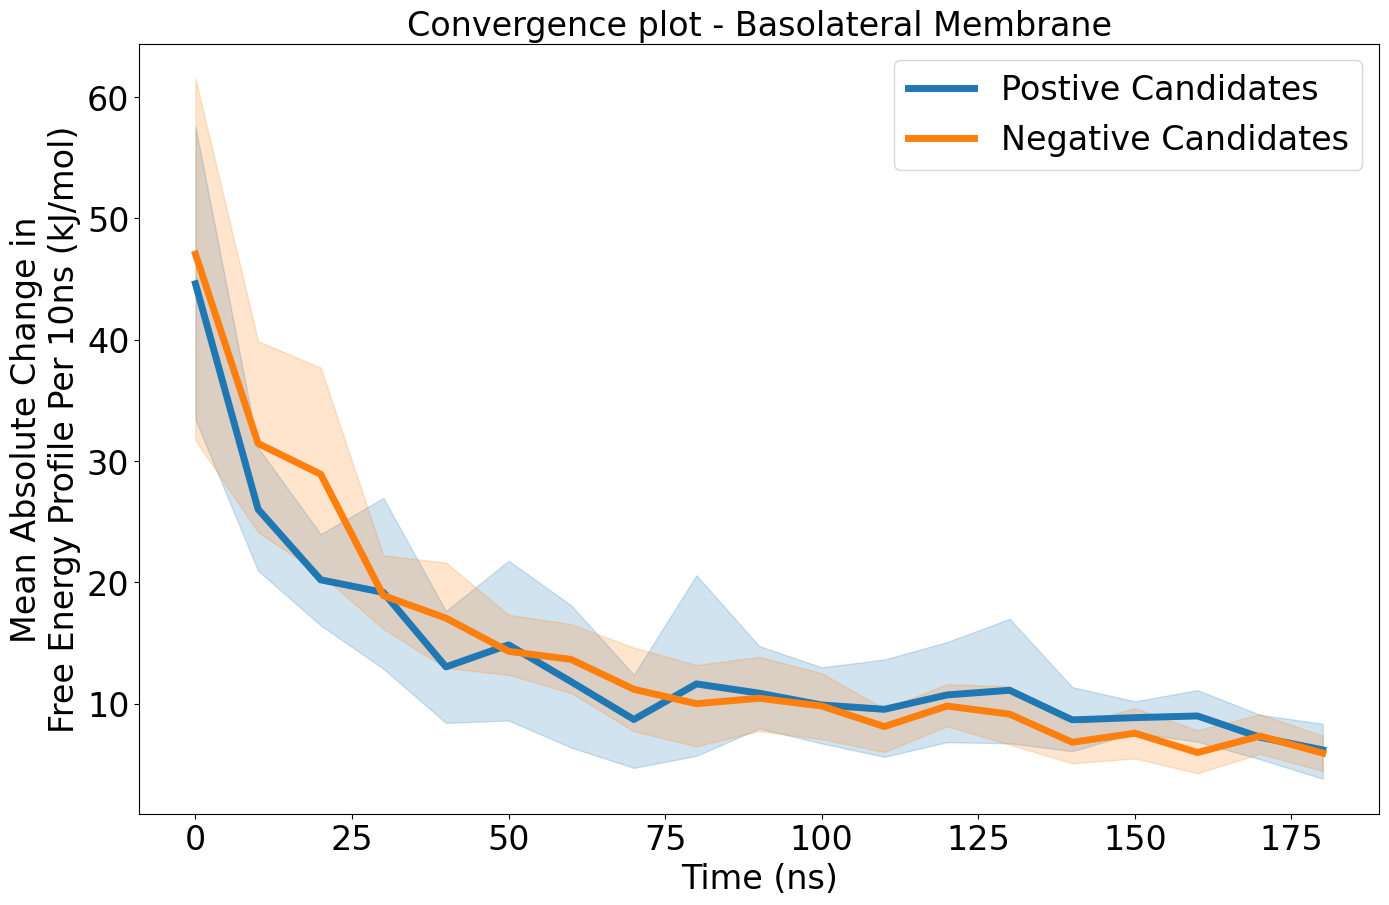

In [11]:
plt.figure(figsize=(16,10))
plt.title('Convergence plot - Basolateral Membrane', fontsize=24)
pos_convergence = []
for i, idx in enumerate(pos_cand['idx']):
    pos_convergence += [compute_convergence(f'../basolateral/candidates/pos/{idx}')]
pos_convergence = pd.concat(pos_convergence)

neg_convergence = []
for i, idx in enumerate(neg_cand['idx']):
    neg_convergence += [compute_convergence(f'../basolateral/candidates/neg/{idx}')]
neg_convergence = pd.concat(neg_convergence)

sns.lineplot(data=pos_convergence, x='time', y='dG', label='Postive Candidates', linewidth=5)
sns.lineplot(data=neg_convergence, x='time', y='dG', label='Negative Candidates', linewidth=5)
plt.xlabel('Time (ns)', fontsize=24)
plt.ylabel('Mean Absolute Change in\nFree Energy Profile Per 10ns (kJ/mol)', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(fontsize=24)
plt.savefig('convergence_basolateral.png')


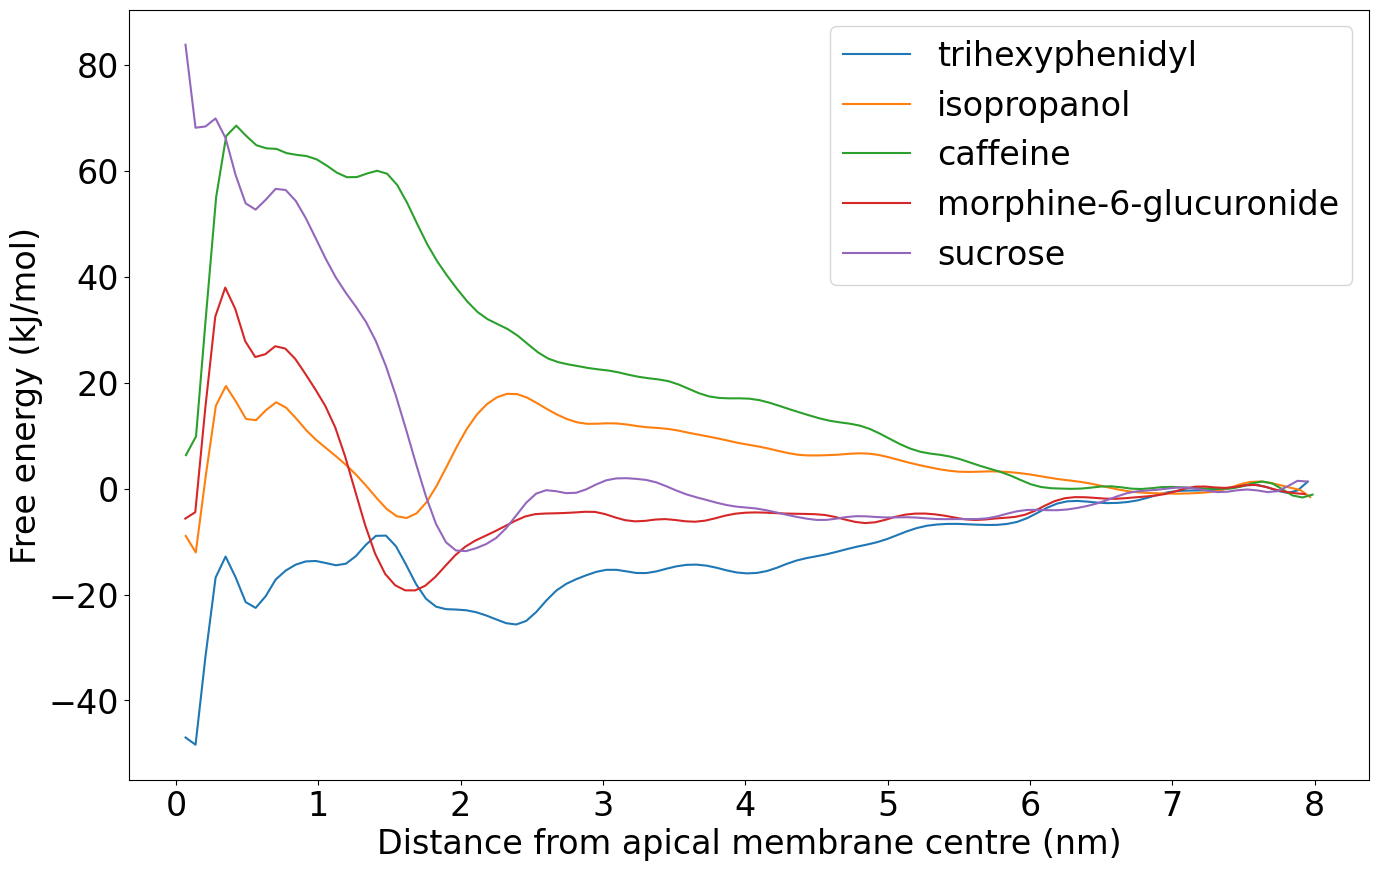

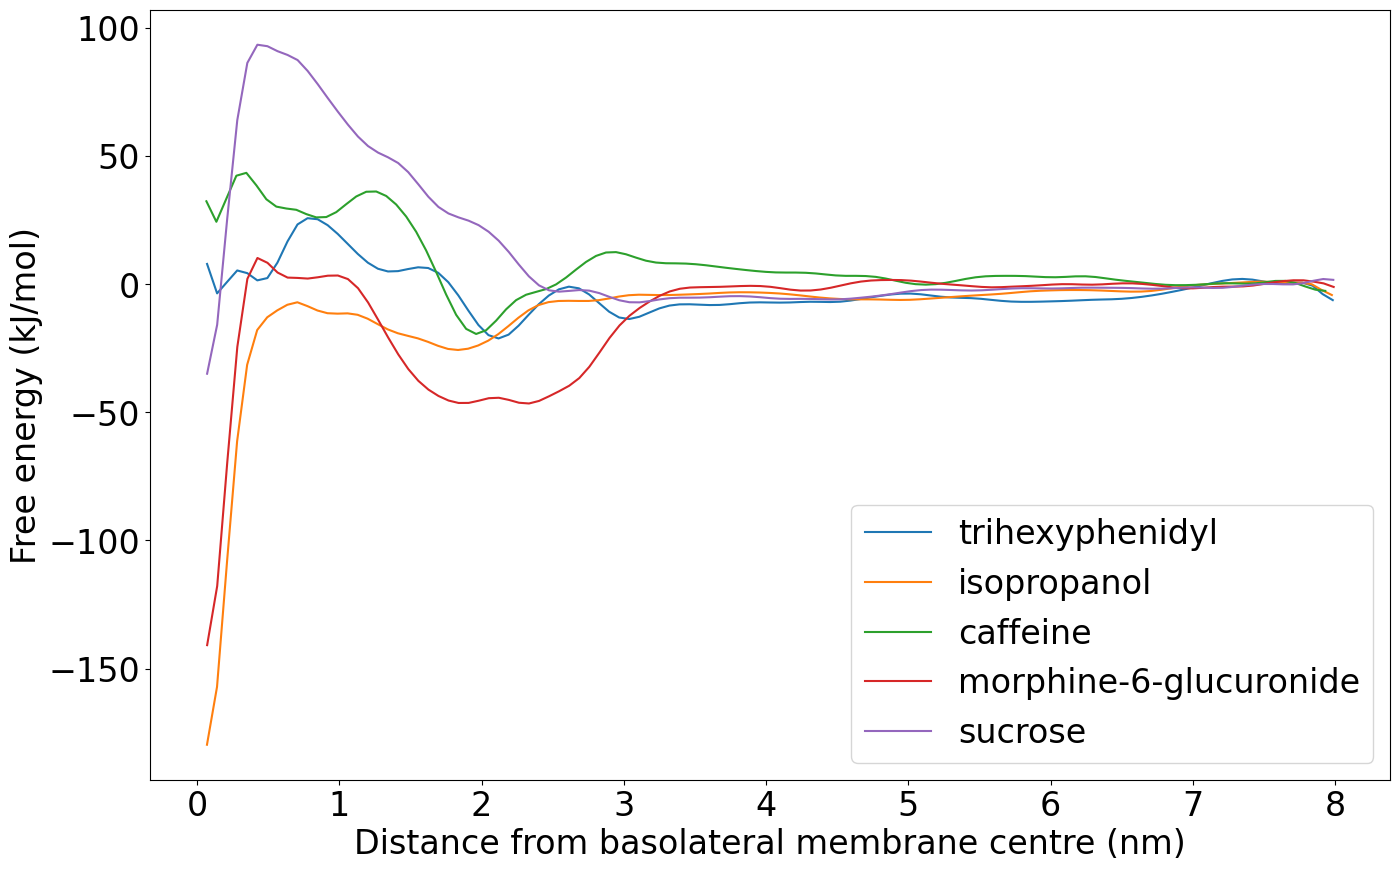

In [12]:
membranes = ('apical', 'basolateral')
molecules = ('trihexyphenidyl', 'isopropanol', 'caffeine', 'morphine-6-glucuronide', 'sucrose')

for mem in membranes:
    plt.figure(figsize=(16, 10))
    for mol in molecules:
        fn = os.path.join("../", mem, "gromacs/", mol, "fes.dat")
        data = pd.read_csv( # Read free energy data from plumed outputs
            fn,
            comment='#',
            sep='\\s+',
            names=['d_abs', 'G', 'dG']
            )
        # Remove out of bounds data
        data = data[(data['d_abs'] > 0) * (data['d_abs'] < 8)]
        # We should shift the zero point of the free energy to the value in the water
        zero_point = data['G'][data['d_abs'] > 7.0].mean()
        data['G'] -= zero_point
        plt.plot(data['d_abs'], data['G'], label=mol)
    
    plt.xlabel("Distance from " + mem + " membrane centre (nm)", fontsize=24)
    plt.ylabel("Free energy (kJ/mol)", fontsize=24)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.legend(fontsize=24)
    plt.savefig("reference_fes_" + mem + ".png")


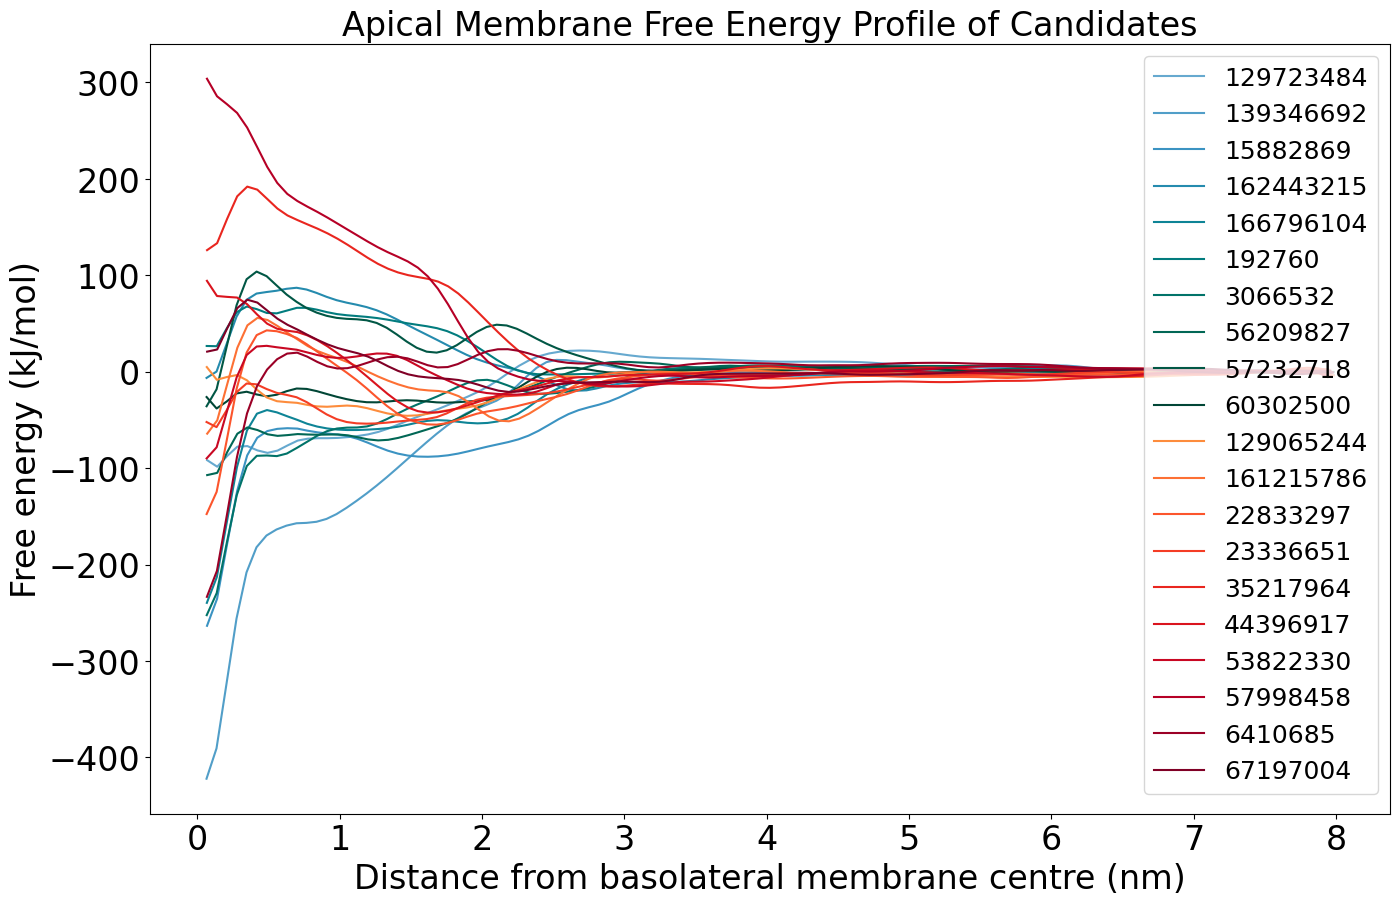

In [13]:
cmap_pos = matplotlib.colormaps['PuBuGn'](np.linspace(0.5, 1, len(pos_cand)))
cmap_neg = matplotlib.colormaps['YlOrRd'](np.linspace(0.5, 1, len(neg_cand)))

plt.figure(figsize=(16, 10))
plt.title('Apical Membrane Free Energy Profile of Candidates', fontsize=24)

for i, idx in enumerate(apical_pos_fes):
    plt.plot(apical_pos_fes[idx]['d_abs'], apical_pos_fes[idx]['G'], label=idx, color=cmap_pos[i])

for i, idx in enumerate(apical_neg_fes):
    plt.plot(apical_neg_fes[idx]['d_abs'], apical_neg_fes[idx]['G'], label=idx, color=cmap_neg[i])

plt.xlabel("Distance from " + mem + " membrane centre (nm)", fontsize=24)
plt.ylabel("Free energy (kJ/mol)", fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(fontsize=18)
plt.savefig("apical_fes.png")

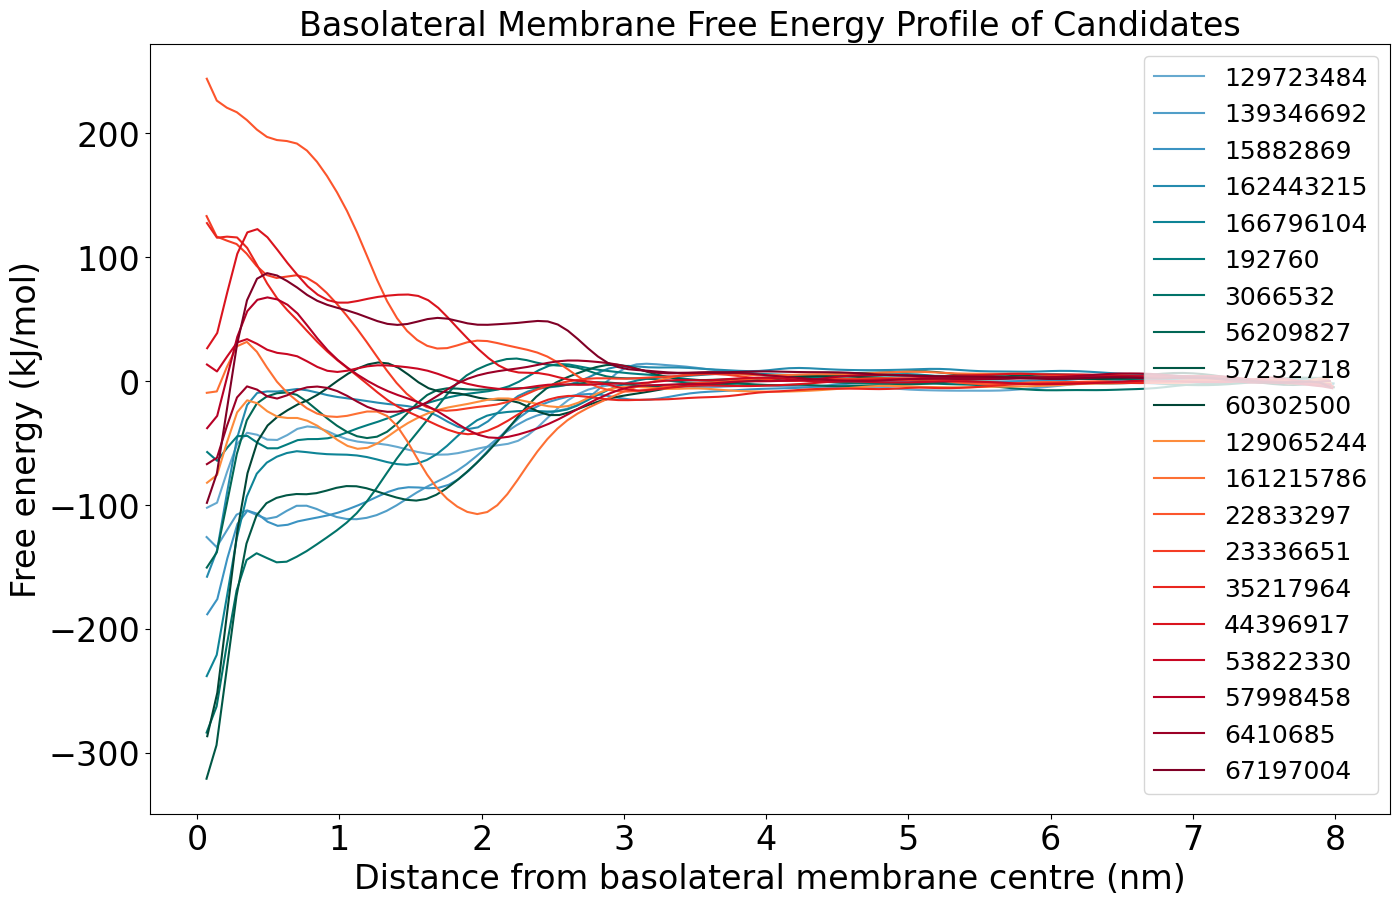

In [14]:
plt.figure(figsize=(16, 10))
plt.title('Basolateral Membrane Free Energy Profile of Candidates', fontsize=24)

for i, idx in enumerate(basolateral_pos_fes):
    plt.plot(basolateral_pos_fes[idx]['d_abs'], basolateral_pos_fes[idx]['G'], label=idx, color=cmap_pos[i])

for i, idx in enumerate(basolateral_neg_fes):
    plt.plot(basolateral_neg_fes[idx]['d_abs'], basolateral_neg_fes[idx]['G'], label=idx, color=cmap_neg[i])

plt.xlabel("Distance from " + mem + " membrane centre (nm)", fontsize=24)
plt.ylabel("Free energy (kJ/mol)", fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(fontsize=18)
plt.savefig("basolateral_fes.png")

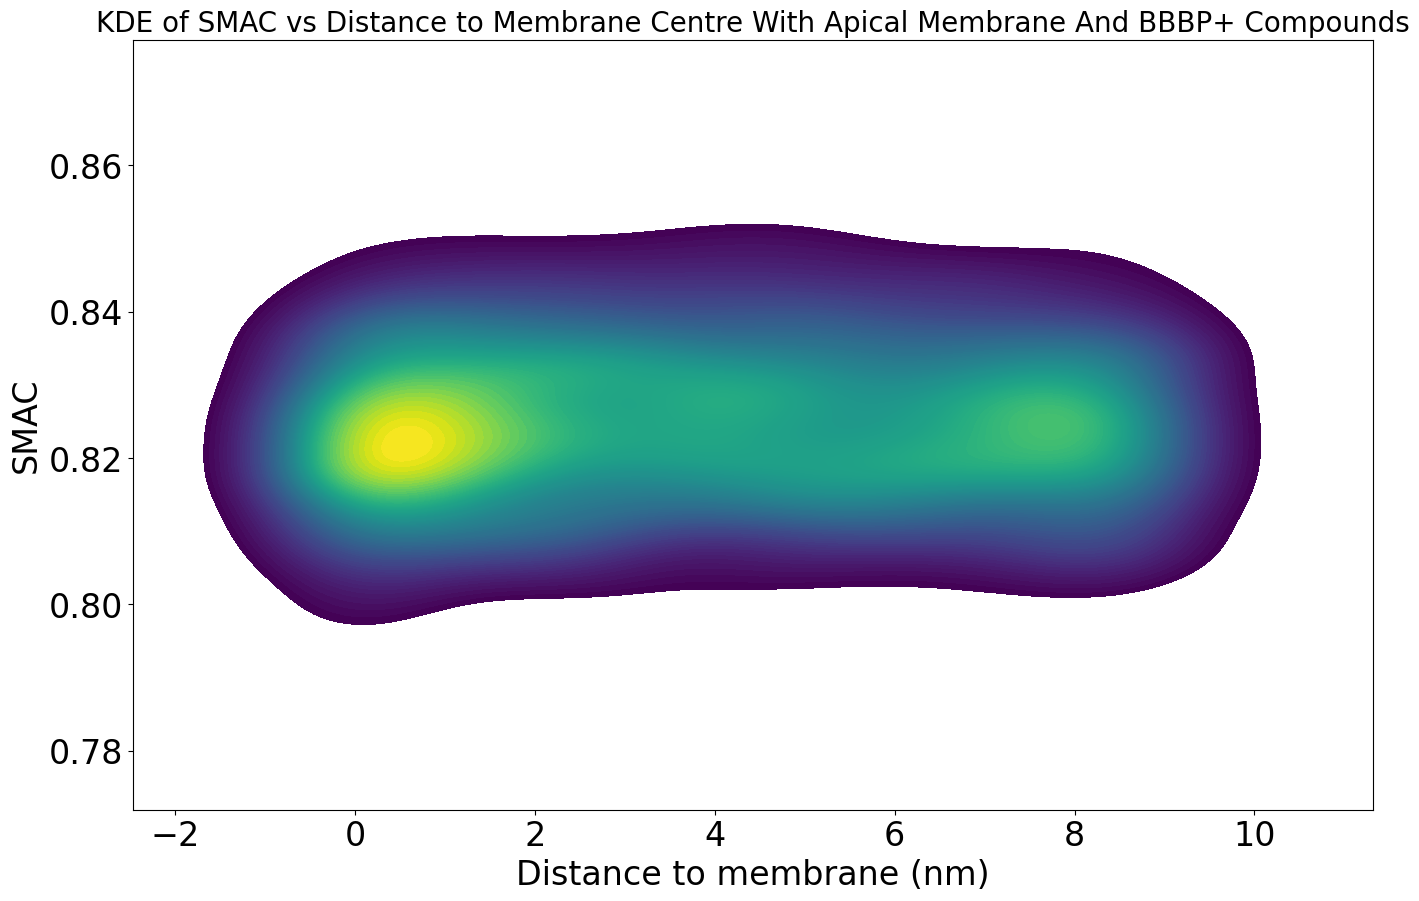

In [15]:
smac = []
for i, row in pos_cand.iterrows():
    data = pd.read_csv( # Read free energy data from plumed outputs
        os.path.join('../apical/candidates/pos/', str(row['idx']), 'smac.txt'),
        comment='#',
        sep='\\s+',
        names=['time', 'd_abs', 'smac']
    )
    smac += [data]
smac = pd.concat(smac, axis=0)

plt.figure(figsize=(16, 10))

sns.kdeplot(x=smac['d_abs'], y=smac['smac'], cmap='viridis', fill=True, thresh=0.05, levels=100)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Distance to membrane (nm)', fontsize=24)
plt.ylabel('SMAC', fontsize=24)
plt.title('KDE of SMAC vs Distance to Membrane Centre With Apical Membrane And BBBP+ Compounds', fontsize=20)
plt.savefig("apical_smac_pos.png")

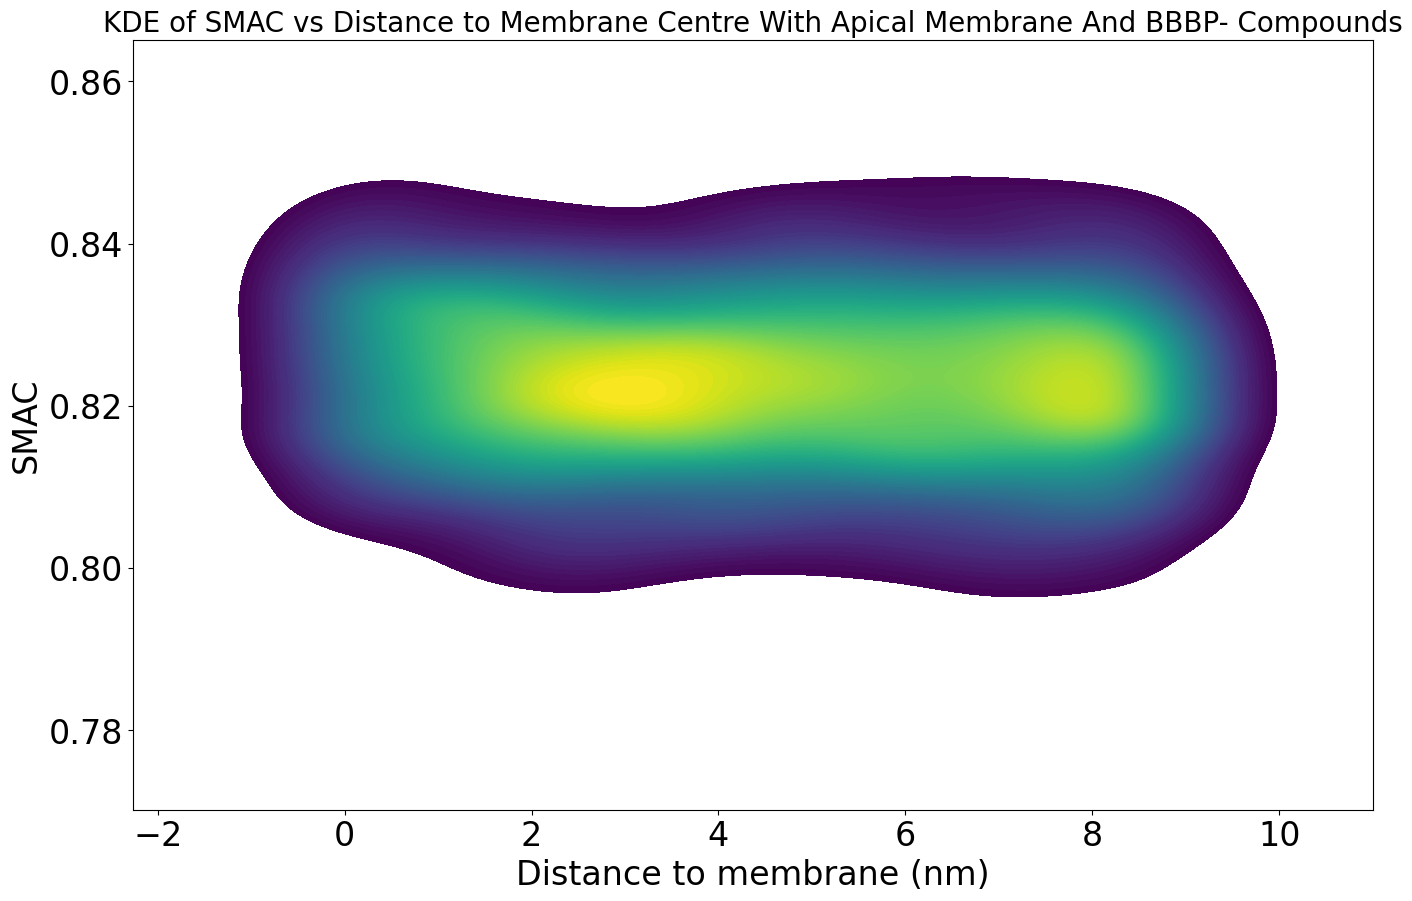

In [16]:
smac = []
for i, row in neg_cand.iterrows():
    data = pd.read_csv( # Read free energy data from plumed outputs
        os.path.join('../apical/candidates/neg/', str(row['idx']), 'smac.txt'),
        comment='#',
        sep='\\s+',
        names=['time', 'd_abs', 'smac']
    )
    smac += [data]
smac = pd.concat(smac, axis=0)

plt.figure(figsize=(16, 10))

sns.kdeplot(x=smac['d_abs'], y=smac['smac'], cmap='viridis', fill=True, thresh=0.05, levels=100)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Distance to membrane (nm)', fontsize=24)
plt.ylabel('SMAC', fontsize=24)
plt.title('KDE of SMAC vs Distance to Membrane Centre With Apical Membrane And BBBP- Compounds', fontsize=20)
plt.savefig("apical_smac_neg.png")

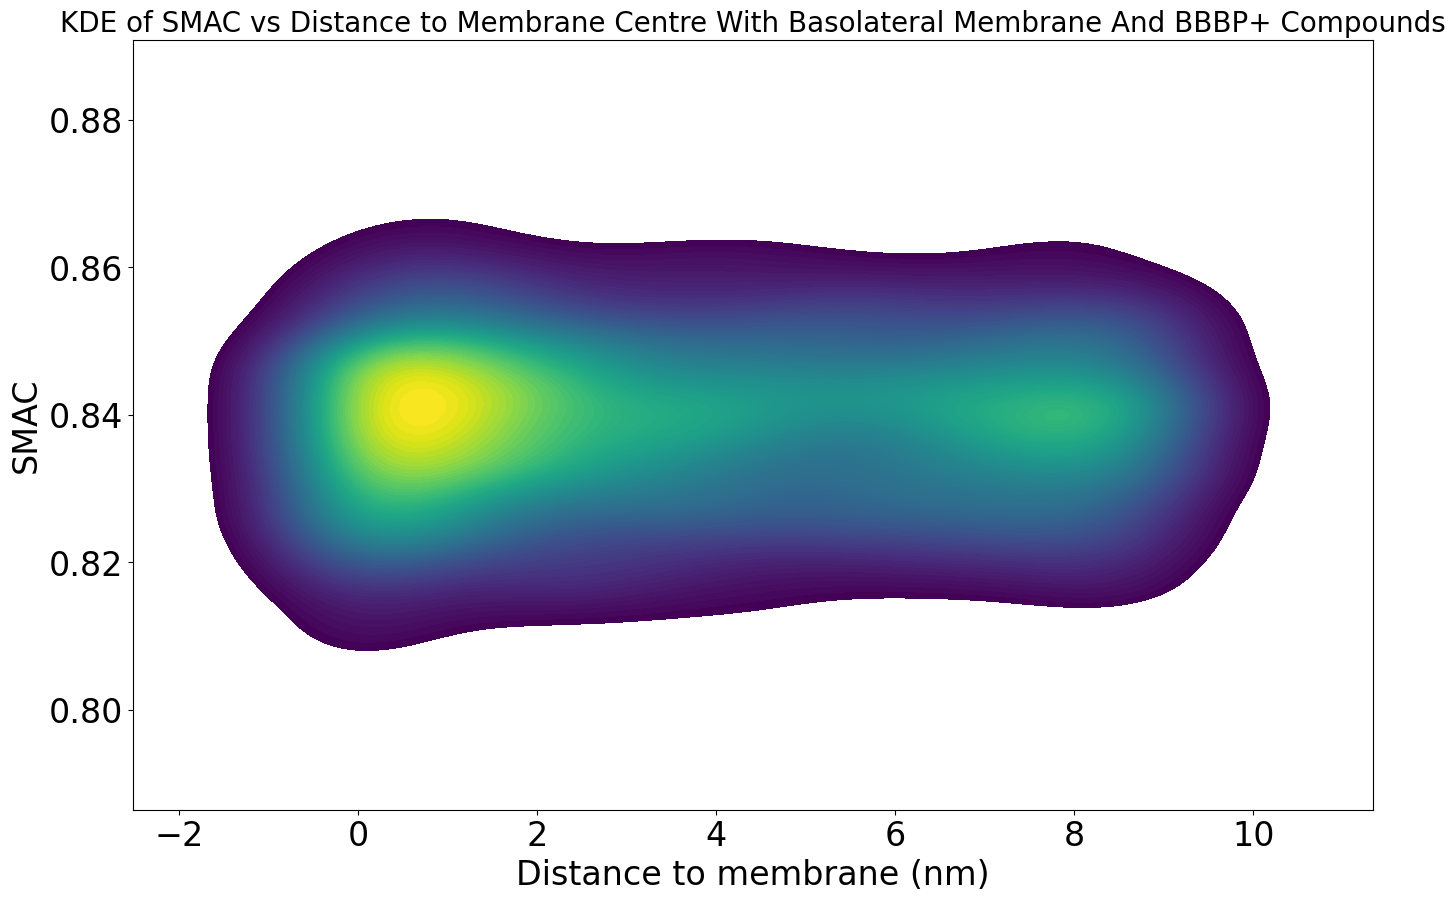

In [17]:
smac = []
for i, row in pos_cand.iterrows():
    data = pd.read_csv( # Read free energy data from plumed outputs
        os.path.join('../basolateral/candidates/pos/', str(row['idx']), 'smac.txt'),
        comment='#',
        sep='\\s+',
        names=['time', 'd_abs', 'smac']
    )
    smac += [data]
smac = pd.concat(smac, axis=0)

plt.figure(figsize=(16, 10))

sns.kdeplot(x=smac['d_abs'], y=smac['smac'], cmap='viridis', fill=True, thresh=0.05, levels=100)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Distance to membrane (nm)', fontsize=24)
plt.ylabel('SMAC', fontsize=24)
plt.title('KDE of SMAC vs Distance to Membrane Centre With Basolateral Membrane And BBBP+ Compounds', fontsize=20)
plt.savefig("basolateral_smac_pos.png")

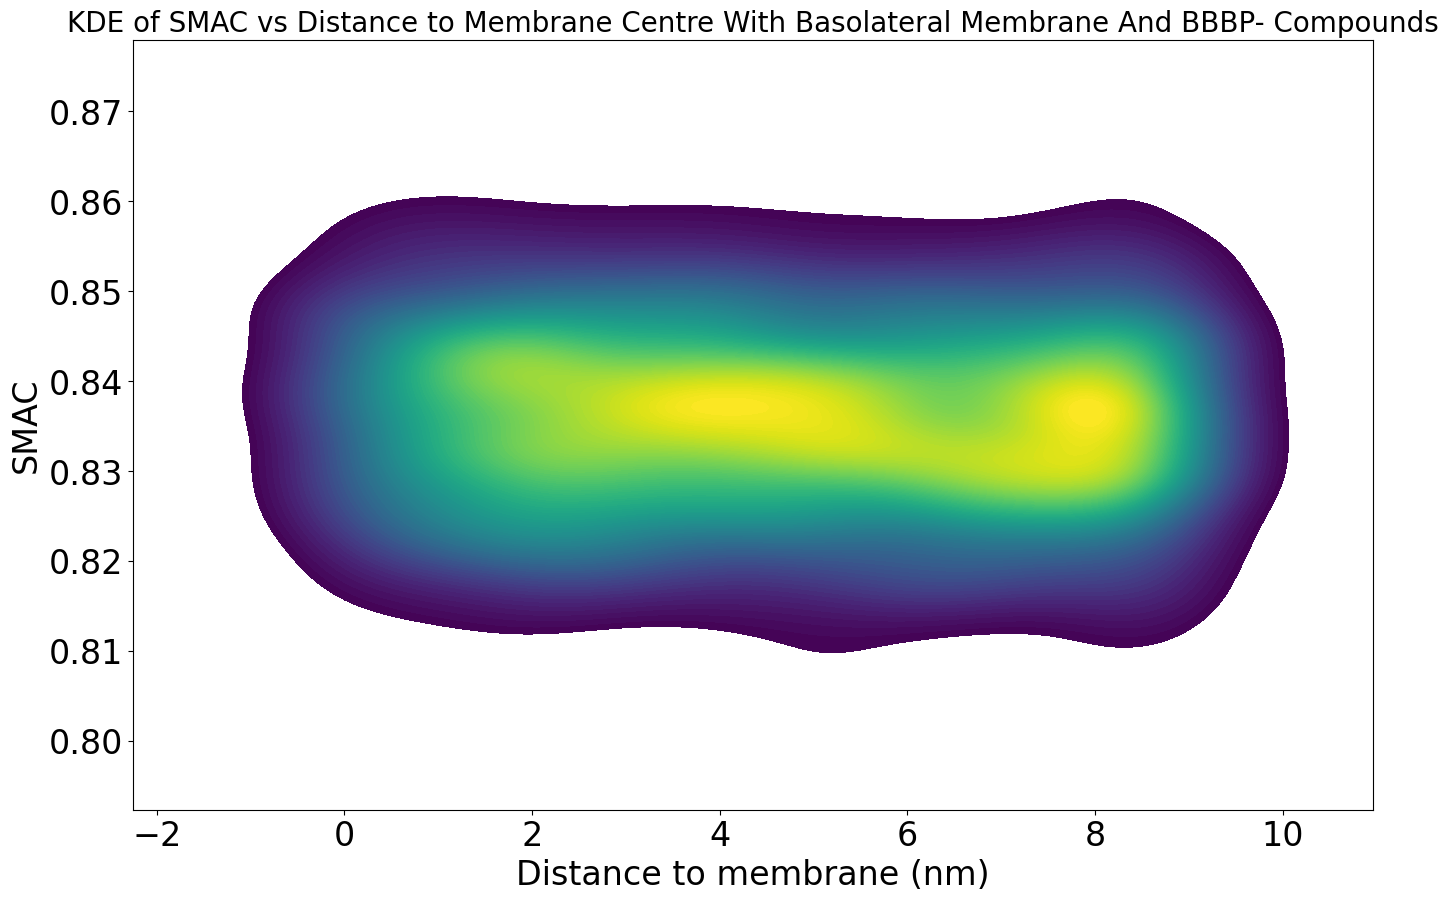

In [18]:
smac = []
for i, row in neg_cand.iterrows():
    data = pd.read_csv( # Read free energy data from plumed outputs
        os.path.join('../basolateral/candidates/neg/', str(row['idx']), 'smac.txt'),
        comment='#',
        sep='\\s+',
        names=['time', 'd_abs', 'smac']
    )
    smac += [data]
smac = pd.concat(smac, axis=0)

plt.figure(figsize=(16, 10))

sns.kdeplot(x=smac['d_abs'], y=smac['smac'], cmap='viridis', fill=True, thresh=0.05, levels=100)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Distance to membrane (nm)', fontsize=24)
plt.ylabel('SMAC', fontsize=24)
plt.title('KDE of SMAC vs Distance to Membrane Centre With Basolateral Membrane And BBBP- Compounds', fontsize=20)
plt.savefig("basolateral_smac_neg.png")

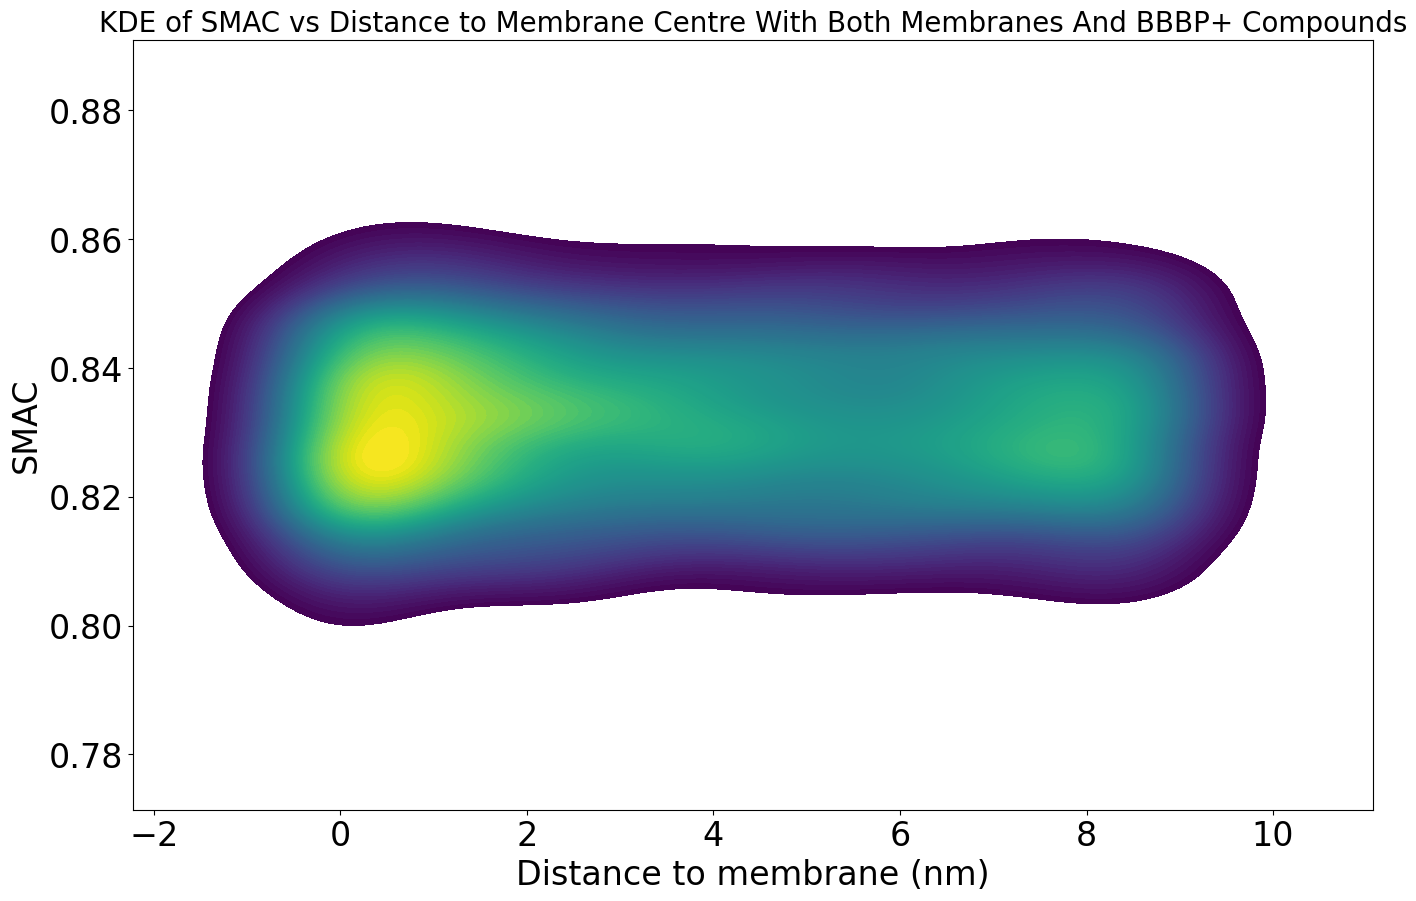

In [19]:
smac = []
for i, row in pos_cand.iterrows():
    data = pd.read_csv( # Read free energy data from plumed outputs
        os.path.join('../basolateral/candidates/pos/', str(row['idx']), 'smac.txt'),
        comment='#',
        sep='\\s+',
        names=['time', 'd_abs', 'smac']
    )
    smac += [data]

    data = pd.read_csv( # Read free energy data from plumed outputs
        os.path.join('../apical/candidates/pos/', str(row['idx']), 'smac.txt'),
        comment='#',
        sep='\\s+',
        names=['time', 'd_abs', 'smac']
    )
    smac += [data]
smac = pd.concat(smac, axis=0)

plt.figure(figsize=(16, 10))

sns.kdeplot(x=smac['d_abs'], y=smac['smac'], cmap='viridis', fill=True, thresh=0.05, levels=100)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Distance to membrane (nm)', fontsize=24)
plt.ylabel('SMAC', fontsize=24)
plt.title('KDE of SMAC vs Distance to Membrane Centre With Both Membranes And BBBP+ Compounds', fontsize=20)
plt.savefig("smac_pos.png")

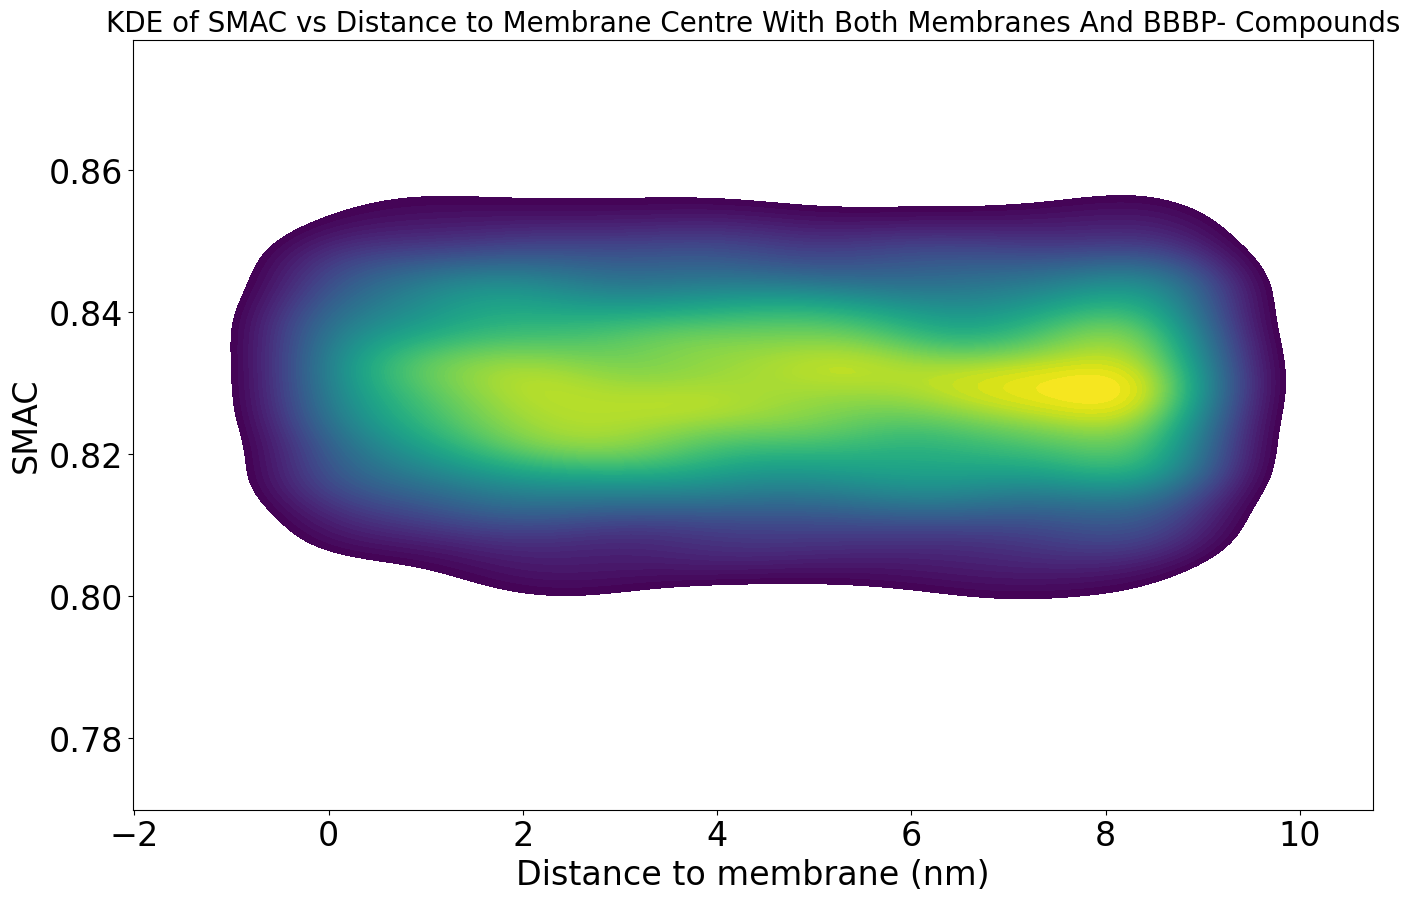

In [20]:
smac = []
for i, row in neg_cand.iterrows():
    data = pd.read_csv( # Read free energy data from plumed outputs
        os.path.join('../basolateral/candidates/neg/', str(row['idx']), 'smac.txt'),
        comment='#',
        sep='\\s+',
        names=['time', 'd_abs', 'smac']
    )
    smac += [data]

    data = pd.read_csv( # Read free energy data from plumed outputs
        os.path.join('../apical/candidates/neg/', str(row['idx']), 'smac.txt'),
        comment='#',
        sep='\\s+',
        names=['time', 'd_abs', 'smac']
    )
    smac += [data]
smac = pd.concat(smac, axis=0)

plt.figure(figsize=(16, 10))

sns.kdeplot(x=smac['d_abs'], y=smac['smac'], cmap='viridis', fill=True, thresh=0.05, levels=100)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.xlabel('Distance to membrane (nm)', fontsize=24)
plt.ylabel('SMAC', fontsize=24)
plt.title('KDE of SMAC vs Distance to Membrane Centre With Both Membranes And BBBP- Compounds', fontsize=20)
plt.savefig("smac_neg.png")